# Installer

In [ ]:
!pip install Sastrawi
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.0 MB/s eta 0:00:00


# Library Import

In [ ]:
import pandas as pd, re, nltk
import numpy as np
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt');
nltk.download('stopwords');
nltk.download('punkt_tab')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Preprocessing

In [ ]:
path_slang = 'colloquial-indonesian-lexicon.csv'
df_slang = pd.read_csv(path_slang)
slang_dict = dict(zip(df_slang['slang'], df_slang['formal']))

def load_dataset(path):
    return pd.read_csv(path).dropna(subset=['review_text']).reset_index(drop=True)

def preprocessing(df):
    stemmer = StemmerFactory().create_stemmer()
    stop_words = set(stopwords.words('indonesian'))

    def process_text(text):
        # A. Case Folding
        text = text.lower()

        # B. Cleansing URL
        text = re.sub(r'http\S+', ' ', text)

        # C. Normalization (Slang to Baku)
        words = text.split()
        text = " ".join([slang_dict.get(w, w) for w in words])

        # D. Cleansing Angka & Simbol
        text = re.sub(r'[0-9]+|[^\w\s]', ' ', text)

        # E. Trim whitespace
        text = text.strip()

        # F. Tokenization
        tokens = word_tokenize(text)

        # G. Stopword Removal & Stemming
        cleaned_tokens = []
        for w in tokens:
            if w not in stop_words and len(w) > 1: # Tambahan: abaikan kata yang cuma 1 huruf
                stemmed_word = stemmer.stem(w)
                cleaned_tokens.append(stemmed_word)

        return " ".join(cleaned_tokens)

    # Terapkan fungsi pada dataframe
    print("Sedang memproses preprocessing... (Sastrawi mungkin agak lambat)")
    df['cleaned_text'] = df['review_text'].apply(process_text)
    print("Preprocessing selesai!")
    return df

In [ ]:
df = load_dataset('Final_Data_v2_Repair.csv')
df.head()

,id,review_text,Atraksi,Aksesbilitas,Amenitas
0,1,Tempat yang baik untuk mendidik anak-anak. Mer...,Positif,Tidak_Ada,Positif
1,2,Berada di sini akhirnya karena saya datang di ...,Negatif,Tidak_Ada,Tidak_Ada
2,3,Adalah tempat yang bagus untuk membawa anak-an...,Negatif,Tidak_Ada,Tidak_Ada
3,4,Ingat terakhir kali saya pergi adalah musim ya...,Tidak_Ada,Tidak_Ada,Negatif
4,5,"Halo, saya ingin mengatakan bahwa jp1 adalah t...",Netral,Positif,Tidak_Ada


In [ ]:
df = preprocessing(df)

Sedang memproses preprocessing... (Sastrawi mungkin agak lambat)
Preprocessing selesai!


In [ ]:
df.iloc[3]['cleaned_text']

'kali pergi musim rendah staf pax minimum jalan omong kosong dorong tix jalan jalan main'

# Distribusi Sentimen

In [ ]:
def check_distribution_pie(df):
    cols = ['Atraksi', 'Aksesbilitas', 'Amenitas']

    # Setup plotting: 1 baris, 3 kolom
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    for i, col in enumerate(cols):
        # 1. Hitung distribusi
        dist = df[col].value_counts()

        # 2. Print Text Distribution untuk dokumentasi
        print(f"Persebaran {col}:")
        print(dist.to_string())
        print("-" * 20)

        # 3. Plotting Pie Chart
        # autopct='%.1f%%' menampilkan persentase dengan 1 angka di belakang koma
        axes[i].pie(dist,
                    labels=dist.index,
                    autopct='%.1f%%',
                    startangle=140,
                    colors=plt.cm.Paired.colors,
                    wedgeprops={'edgecolor': 'white'})

        axes[i].set_title(f'Persentase Aspek: {col}', fontsize=14, pad=20)

    plt.tight_layout()
    plt.show()

Persebaran Atraksi:
Atraksi
Positif      3200
Netral        231
Negatif       149
Tidak_Ada     112
--------------------
Persebaran Aksesbilitas:
Aksesbilitas
Tidak_Ada    3232
Positif       317
Negatif       100
Netral         43
--------------------
Persebaran Amenitas:
Amenitas
Tidak_Ada    2556
Positif       826
Negatif       207
Netral        103
--------------------


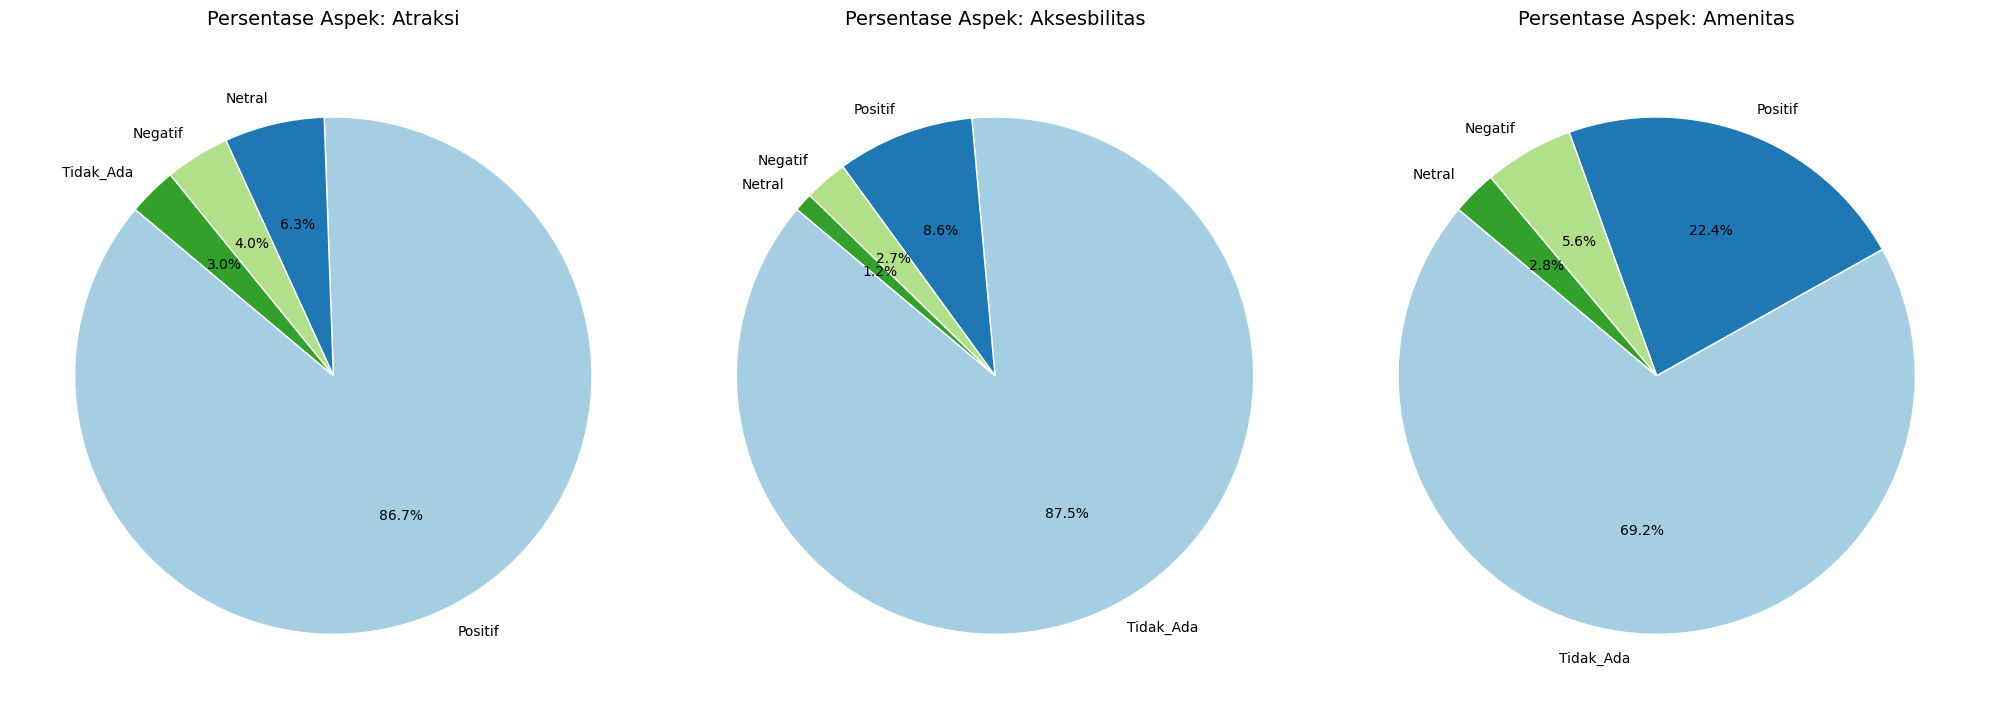

In [ ]:
check_distribution_pie(df)

# Ekstraksi Fitur TF-IDF

In [ ]:
def get_tfidf_features(df, max_features=10000):
    """
    Fungsi untuk mengekstrak fitur TF-IDF dari kolom 'cleaned_text'.

    Parameters:
    df (pd.DataFrame): DataFrame yang berisi data.
    max_features (int): Jumlah maksimal fitur kata yang diambil.

    Returns:
    X (sparse matrix): Hasil vektorisasi TF-IDF.
    tfidf (object): Objek TfidfVectorizer yang sudah di-fit.
    """

    # Inisialisasi TfidfVectorizer
    tfidf = TfidfVectorizer(max_features=max_features)

    # Fit dan Transform pada kolom cleaned_text
    X = tfidf.fit_transform(df['cleaned_text'])

    # Mendapatkan informasi jumlah fitur
    print(f"TF-IDF Berhasil Dibuat!")
    print(f"Jumlah baris: {X.shape[0]}")
    print(f"Jumlah fitur (kata): {X.shape[1]}")

    return X, tfidf

# --- Cara Penggunaan ---
# X_tfidf, vectorizer = get_tfidf_features(df)

# Random Forest

In [ ]:
def run_strategic_experiment(df, X_tfidf, tfidf_model, test_size, n_estimators, scenario_label):
    aspek_cols = ['Atraksi', 'Aksesbilitas', 'Amenitas']

    print(f"\n{'='*70}")
    print(f"EVALUASI SKENARIO: {scenario_label.upper()}")
    print(f"{'='*70}")

    results_l1 = []
    results_l2 = []

    # Loop Proses Klasifikasi
    for col_name in aspek_cols:
        # --- LEVEL 1: ACD (Sentimen vs Non-Sentimen) ---
        y_l1 = df[col_name].apply(lambda x: 1 if x in ['Positif', 'Negatif'] else 0)
        X_train1, X_test1, y_train1, y_test1 = train_test_split(
            X_tfidf, y_l1, test_size=test_size, random_state=42, stratify=y_l1
        )
        model_l1 = RandomForestClassifier(n_estimators=n_estimators, random_state=42, n_jobs=-1,class_weight='balanced')
        model_l1.fit(X_train1, y_train1)
        y_pred1 = model_l1.predict(X_test1)
        results_l1.append((y_test1, y_pred1, col_name))

        # --- LEVEL 2: APC (Positif vs Negatif) ---
        df_l2 = df[df[col_name].isin(['Positif', 'Negatif'])]
        if len(df_l2) > 10:
            X_l2 = tfidf_model.transform(df_l2['cleaned_text'])
            y_l2 = df_l2[col_name]
            X_train2, X_test2, y_train2, y_test2 = train_test_split(
                X_l2, y_l2, test_size=test_size, random_state=42, stratify=y_l2
            )
            model_l2 = RandomForestClassifier(n_estimators=n_estimators, random_state=42, n_jobs=-1,class_weight='balanced')
            model_l2.fit(X_train2, y_train2)
            y_pred2 = model_l2.predict(X_test2)
            results_l2.append((y_test2, y_pred2, col_name))
        else:
            results_l2.append((None, None, col_name))

    # --- OUTPUT EVALUASI LEVEL 1 ---
    print(f"\n[Hasil Metriks Tahap 1: Klasifikasi Aspek]")
    for y_true, y_pred, name in results_l1:
        print(f"\n>>> Aspek: {name} <<<")
        print(classification_report(y_true, y_pred, target_names=['Non-Sentimen', 'Sentimen'], zero_division=0))

    print("\n[DISPLAYING CONFUSION MATRICES Tahap 1]")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Klasifikasi Aspek: Sentimen vs Non-Sentimen ({scenario_label})", fontsize=16)
    for idx, (y_true, y_pred, name) in enumerate(results_l1):
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Sentimen', 'Sentimen'])
        disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
        axes[idx].set_title(f"Aspek: {name}")
    plt.tight_layout()
    plt.show()

    # --- OUTPUT EVALUASI LEVEL 2 ---
    print(f"\n\n[Hasil Metriks Tahap 2: Klasifikasi Sentimen]")
    for y_true, y_pred, name in results_l2:
        print(f"\n>>> Aspek: {name} <<<")
        if y_true is not None:
            print(classification_report(y_true, y_pred, zero_division=0))
        else:
            print("Hasil: Data tidak mencukupi untuk evaluasi (n < 10).")

    print("\n[DISPLAYING CONFUSION MATRICES Tahap 2]")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Level 2: Positif vs Negatif ({scenario_label})", fontsize=16)
    for idx, (y_true, y_pred, name) in enumerate(results_l2):
        if y_true is not None:
            cm = confusion_matrix(y_true, y_pred)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negatif', 'Positif'])
            disp.plot(ax=axes[idx], cmap='Reds', colorbar=False)
            axes[idx].set_title(f"Aspek: {name}")
        else:
            axes[idx].text(0.5, 0.5, "Data tidak cukup", ha='center', va='center')
            axes[idx].set_title(f"Aspek: {name} (N/A)")
    plt.tight_layout()
    plt.show()

In [ ]:
# Ambil fitur
X_tfidf, tfidf_model = get_tfidf_features(df)


TF-IDF Berhasil Dibuat!
Jumlah baris: 3692
Jumlah fitur (kata): 6355



EVALUASI SKENARIO: SKENARIO KE-1 70:30 - 100 N_EST

[Hasil Metriks Tahap 1: Klasifikasi Aspek]

>>> Aspek: Atraksi <<<
              precision    recall  f1-score   support

Non-Sentimen       1.00      0.06      0.11       103
    Sentimen       0.91      1.00      0.95      1005

    accuracy                           0.91      1108
   macro avg       0.96      0.53      0.53      1108
weighted avg       0.92      0.91      0.88      1108


>>> Aspek: Aksesbilitas <<<
              precision    recall  f1-score   support

Non-Sentimen       0.90      1.00      0.95       983
    Sentimen       0.93      0.10      0.19       125

    accuracy                           0.90      1108
   macro avg       0.91      0.55      0.57      1108
weighted avg       0.90      0.90      0.86      1108


>>> Aspek: Amenitas <<<
              precision    recall  f1-score   support

Non-Sentimen       0.83      0.95      0.89       798
    Sentimen       0.81      0.51      0.62       310

    accu

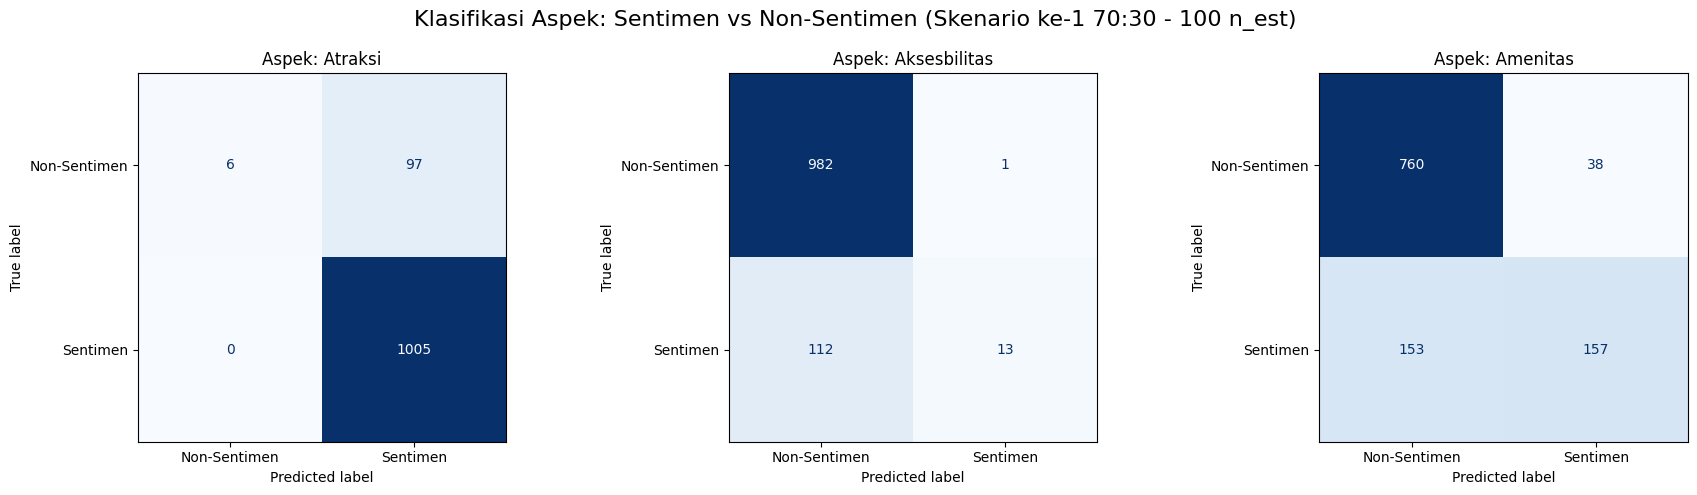



[Hasil Metriks Tahap 2: Klasifikasi Sentimen]

>>> Aspek: Atraksi <<<
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00        45
     Positif       0.96      1.00      0.98       960

    accuracy                           0.96      1005
   macro avg       0.48      0.50      0.49      1005
weighted avg       0.91      0.96      0.93      1005


>>> Aspek: Aksesbilitas <<<
              precision    recall  f1-score   support

     Negatif       0.77      0.33      0.47        30
     Positif       0.82      0.97      0.89        96

    accuracy                           0.82       126
   macro avg       0.80      0.65      0.68       126
weighted avg       0.81      0.82      0.79       126


>>> Aspek: Amenitas <<<
              precision    recall  f1-score   support

     Negatif       0.87      0.32      0.47        62
     Positif       0.85      0.99      0.92       248

    accuracy                           0.85       310
  

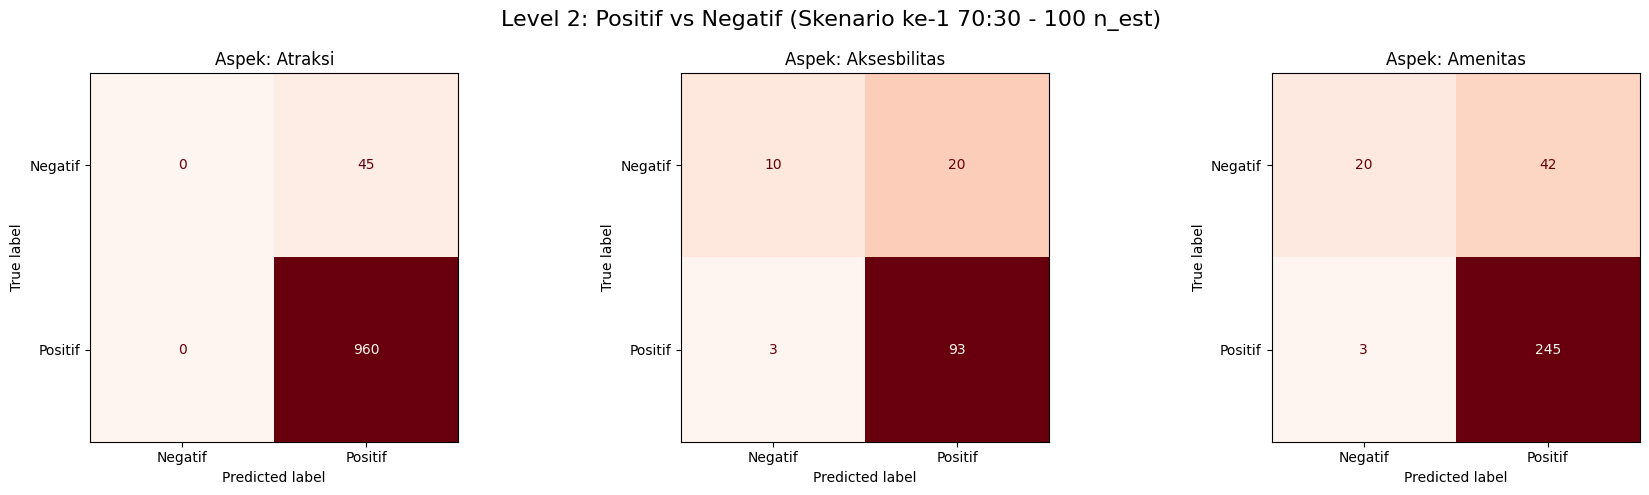

In [ ]:
# Jalankan skenario yang ingin dipantau
run_strategic_experiment(df, X_tfidf, tfidf_model, 0.3, 100, "Skenario ke-1 70:30 - 100 n_est")


EVALUASI SKENARIO: SKENARIO KE-2 70:30 - 200 N_EST

[Hasil Metriks Tahap 1: Klasifikasi Aspek]

>>> Aspek: Atraksi <<<
              precision    recall  f1-score   support

Non-Sentimen       1.00      0.05      0.09       103
    Sentimen       0.91      1.00      0.95      1005

    accuracy                           0.91      1108
   macro avg       0.96      0.52      0.52      1108
weighted avg       0.92      0.91      0.87      1108


>>> Aspek: Aksesbilitas <<<
              precision    recall  f1-score   support

Non-Sentimen       0.90      1.00      0.95       983
    Sentimen       0.92      0.10      0.17       125

    accuracy                           0.90      1108
   macro avg       0.91      0.55      0.56      1108
weighted avg       0.90      0.90      0.86      1108


>>> Aspek: Amenitas <<<
              precision    recall  f1-score   support

Non-Sentimen       0.84      0.96      0.89       798
    Sentimen       0.82      0.53      0.65       310

    accu

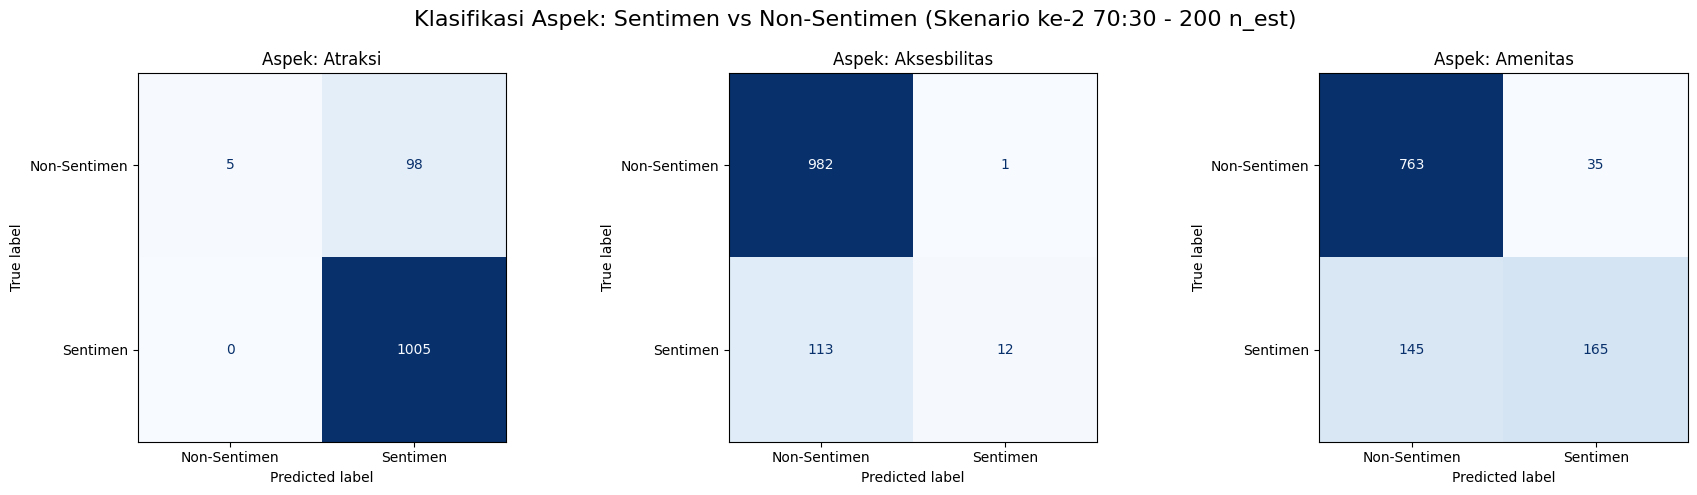



[Hasil Metriks Tahap 2: Klasifikasi Sentimen]

>>> Aspek: Atraksi <<<
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00        45
     Positif       0.96      1.00      0.98       960

    accuracy                           0.96      1005
   macro avg       0.48      0.50      0.49      1005
weighted avg       0.91      0.96      0.93      1005


>>> Aspek: Aksesbilitas <<<
              precision    recall  f1-score   support

     Negatif       0.80      0.40      0.53        30
     Positif       0.84      0.97      0.90        96

    accuracy                           0.83       126
   macro avg       0.82      0.68      0.72       126
weighted avg       0.83      0.83      0.81       126


>>> Aspek: Amenitas <<<
              precision    recall  f1-score   support

     Negatif       0.91      0.32      0.48        62
     Positif       0.85      0.99      0.92       248

    accuracy                           0.86       310
  

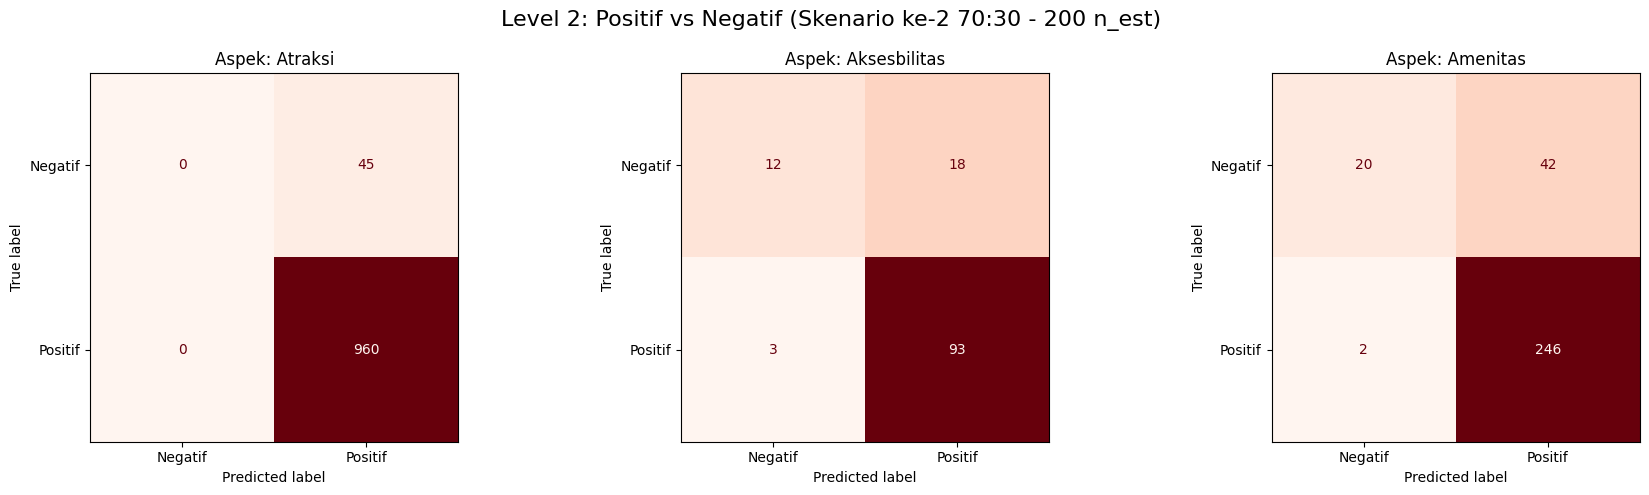

In [ ]:
run_strategic_experiment(df, X_tfidf, tfidf_model, 0.3, 200, "Skenario ke-2 70:30 - 200 n_est")


EVALUASI SKENARIO: SKENARIO KE-3 80:20 - 100 N_EST

[Hasil Metriks Tahap 1: Klasifikasi Aspek]

>>> Aspek: Atraksi <<<
              precision    recall  f1-score   support

Non-Sentimen       0.60      0.09      0.15        69
    Sentimen       0.91      0.99      0.95       670

    accuracy                           0.91       739
   macro avg       0.76      0.54      0.55       739
weighted avg       0.88      0.91      0.88       739


>>> Aspek: Aksesbilitas <<<
              precision    recall  f1-score   support

Non-Sentimen       0.90      1.00      0.95       656
    Sentimen       1.00      0.11      0.20        83

    accuracy                           0.90       739
   macro avg       0.95      0.55      0.57       739
weighted avg       0.91      0.90      0.86       739


>>> Aspek: Amenitas <<<
              precision    recall  f1-score   support

Non-Sentimen       0.85      0.96      0.90       532
    Sentimen       0.85      0.58      0.69       207

    accu

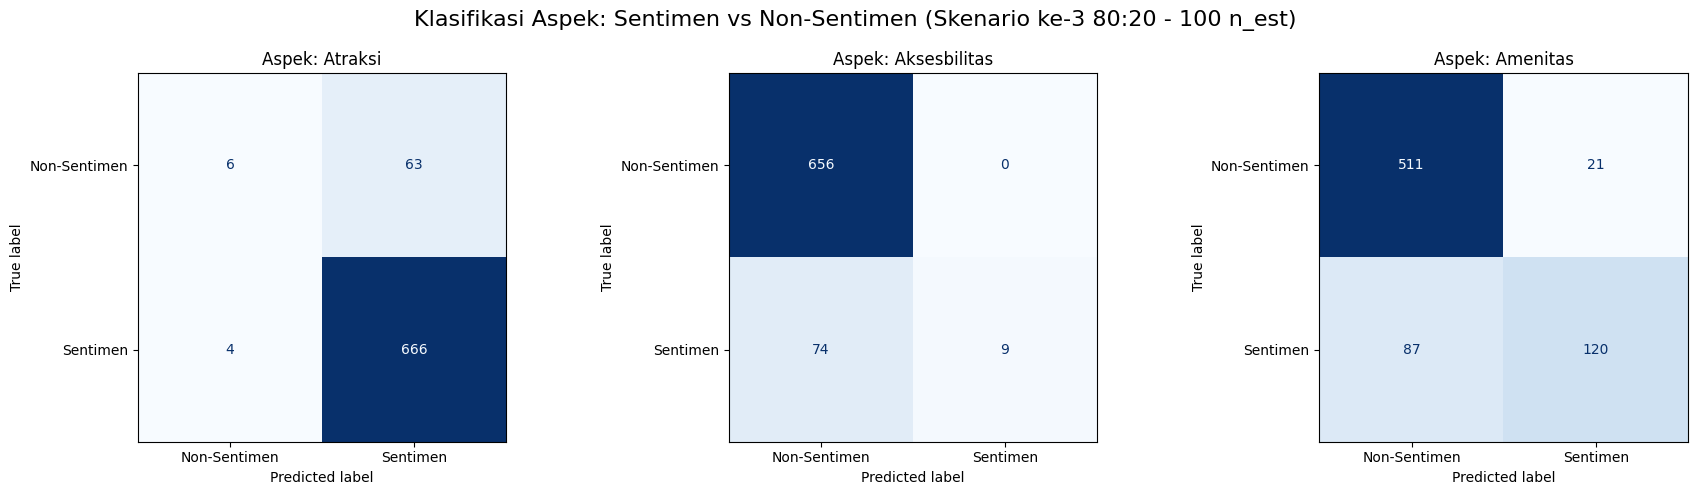



[Hasil Metriks Tahap 2: Klasifikasi Sentimen]

>>> Aspek: Atraksi <<<
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00        30
     Positif       0.96      1.00      0.98       640

    accuracy                           0.96       670
   macro avg       0.48      0.50      0.49       670
weighted avg       0.91      0.96      0.93       670


>>> Aspek: Aksesbilitas <<<
              precision    recall  f1-score   support

     Negatif       0.85      0.55      0.67        20
     Positif       0.87      0.97      0.92        64

    accuracy                           0.87        84
   macro avg       0.86      0.76      0.79        84
weighted avg       0.87      0.87      0.86        84


>>> Aspek: Amenitas <<<
              precision    recall  f1-score   support

     Negatif       0.91      0.49      0.63        41
     Positif       0.89      0.99      0.93       166

    accuracy                           0.89       207
  

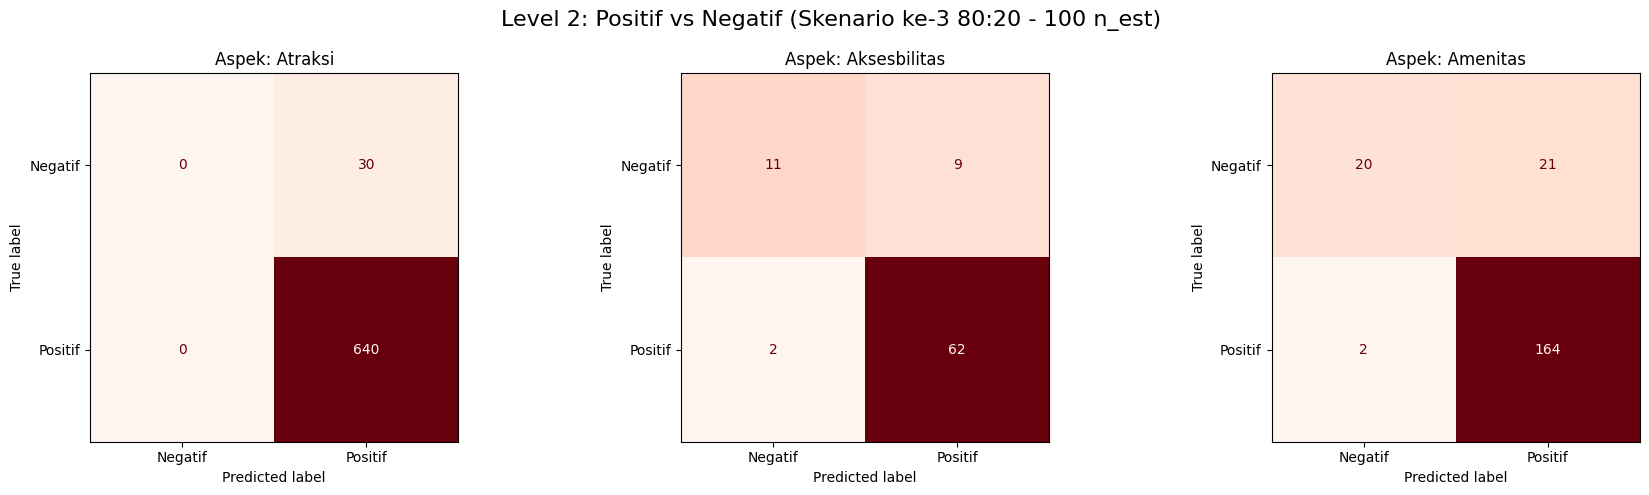

In [ ]:
run_strategic_experiment(df, X_tfidf, tfidf_model, 0.2, 100, "Skenario ke-3 80:20 - 100 n_est")


EVALUASI SKENARIO: SKENARIO KE-4 80:20 - 200 N_EST

[Hasil Metriks Tahap 1: Klasifikasi Aspek]

>>> Aspek: Atraksi <<<
              precision    recall  f1-score   support

Non-Sentimen       0.80      0.06      0.11        69
    Sentimen       0.91      1.00      0.95       670

    accuracy                           0.91       739
   macro avg       0.86      0.53      0.53       739
weighted avg       0.90      0.91      0.87       739


>>> Aspek: Aksesbilitas <<<
              precision    recall  f1-score   support

Non-Sentimen       0.90      1.00      0.95       656
    Sentimen       1.00      0.08      0.16        83

    accuracy                           0.90       739
   macro avg       0.95      0.54      0.55       739
weighted avg       0.91      0.90      0.86       739


>>> Aspek: Amenitas <<<
              precision    recall  f1-score   support

Non-Sentimen       0.86      0.96      0.91       532
    Sentimen       0.85      0.59      0.70       207

    accu

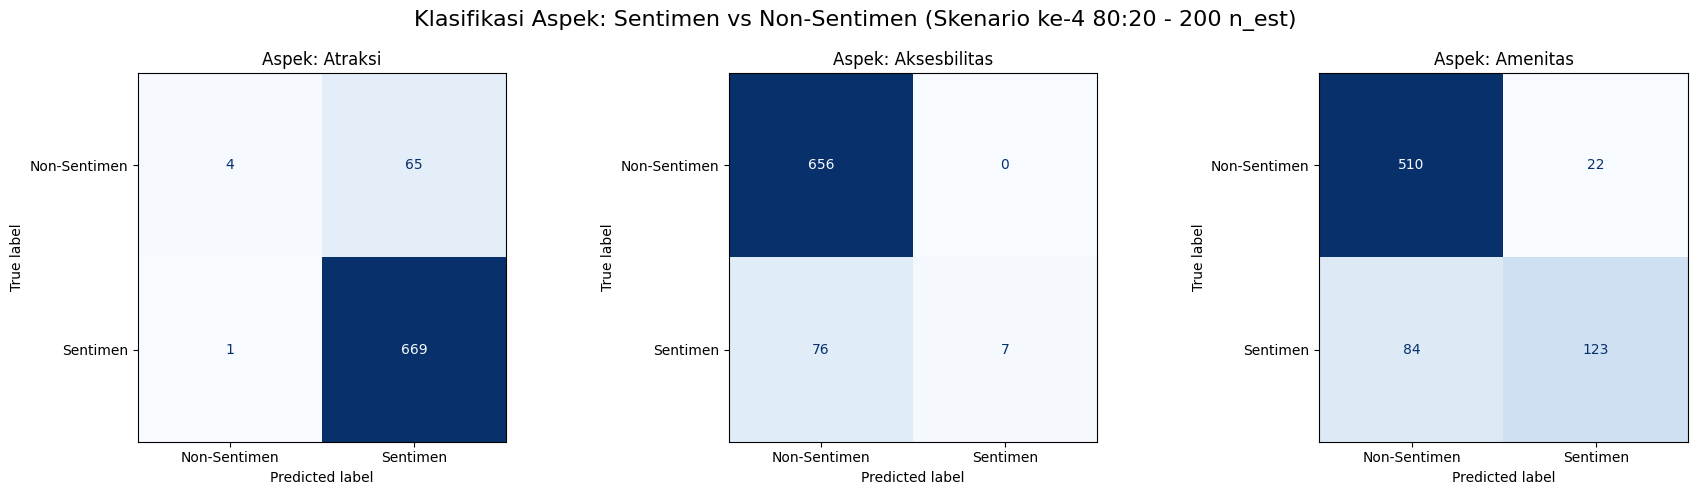



[Hasil Metriks Tahap 2: Klasifikasi Sentimen]

>>> Aspek: Atraksi <<<
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00        30
     Positif       0.96      1.00      0.98       640

    accuracy                           0.96       670
   macro avg       0.48      0.50      0.49       670
weighted avg       0.91      0.96      0.93       670


>>> Aspek: Aksesbilitas <<<
              precision    recall  f1-score   support

     Negatif       0.83      0.50      0.62        20
     Positif       0.86      0.97      0.91        64

    accuracy                           0.86        84
   macro avg       0.85      0.73      0.77        84
weighted avg       0.85      0.86      0.84        84


>>> Aspek: Amenitas <<<
              precision    recall  f1-score   support

     Negatif       0.95      0.46      0.62        41
     Positif       0.88      0.99      0.93       166

    accuracy                           0.89       207
  

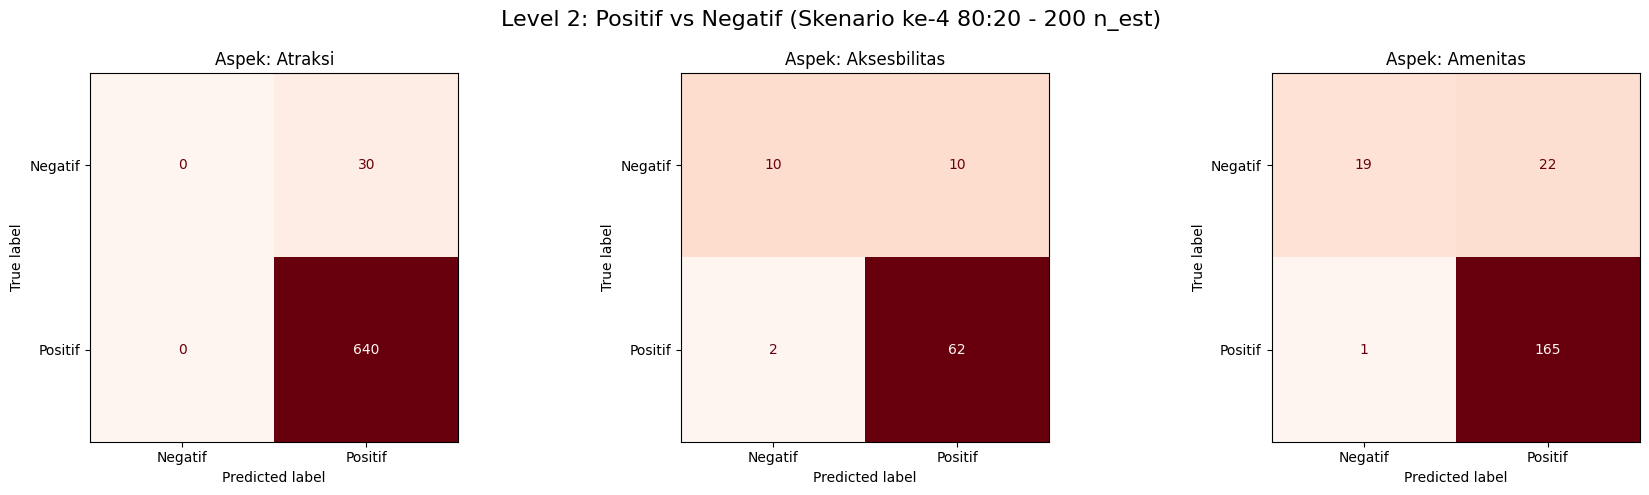

In [ ]:
run_strategic_experiment(df, X_tfidf, tfidf_model, 0.2, 200, "Skenario ke-4 80:20 - 200 n_est")

# Visualisasi

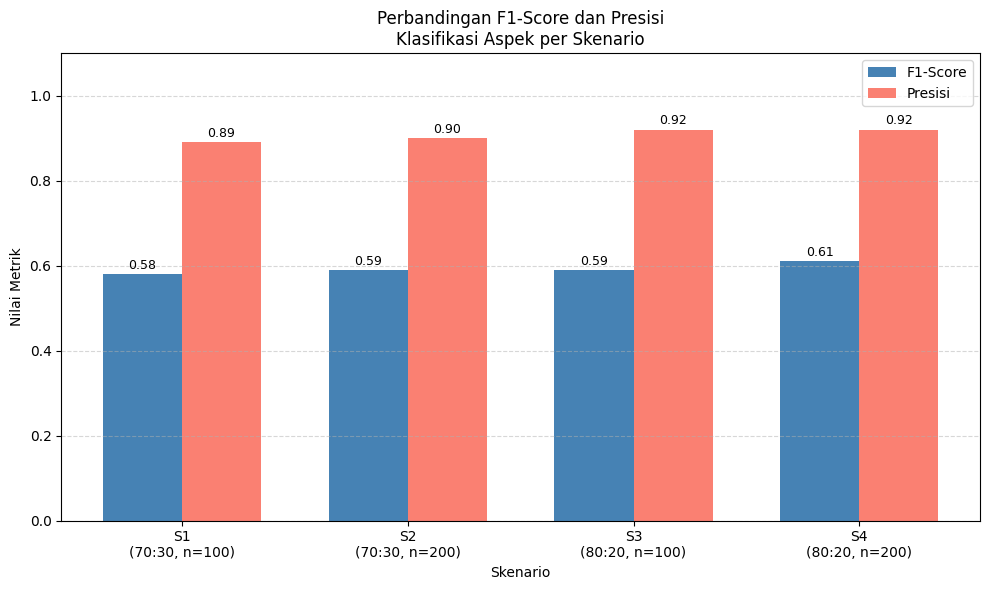

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Import Data ──────────────────────────────────────────────
df_aspek = pd.read_excel('Klasifikasi_Aspek.xlsx')
df_sentimen = pd.read_excel('Klasifikasi_Sentimen.xlsx')

# Pastikan kolom konsisten
df_aspek.columns = ['Skenario', 'Rasio', 'N_Estimators', 'Akurasi', 'Presisi', 'Recall', 'F1-Score']
df_sentimen.columns = ['Skenario', 'Rasio', 'N_Estimators', 'Akurasi', 'Presisi', 'Recall', 'F1-Score']

label_skenario = ['S1\n(70:30, n=100)', 'S2\n(70:30, n=200)', 'S3\n(80:20, n=100)', 'S4\n(80:20, n=200)']
# Konversi eksplisit kolom numerik jika masih string
for col in ['Akurasi', 'Presisi', 'Recall', 'F1-Score']:
    df_aspek[col] = pd.to_numeric(df_aspek[col].astype(str).str.replace(',', '.'), errors='coerce')
    df_sentimen[col] = pd.to_numeric(df_sentimen[col].astype(str).str.replace(',', '.'), errors='coerce')


# ── 2. Grouped Bar Chart — F1 & Presisi L1 Klasifikasi Aspek ────
def plot_grouped_bar(df_aspek):
    x = np.arange(len(df_aspek))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    bars1 = ax.bar(x - width/2, df_aspek['F1-Score'], width, label='F1-Score', color='steelblue')
    bars2 = ax.bar(x + width/2, df_aspek['Presisi'], width, label='Presisi', color='salmon')

    # Label nilai di atas batang
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('Skenario')
    ax.set_ylabel('Nilai Metrik')
    ax.set_title('Perbandingan F1-Score dan Presisi\nKlasifikasi Aspek per Skenario')
    ax.set_xticks(x)
    ax.set_xticklabels(label_skenario)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('grouped_bar_aspek.png', dpi=300)
    plt.show()


# ── 3. Line Chart — Tren F1 L1 vs L2 ───────────────────────────
def plot_line_chart(df_aspek, df_sentimen):
    x = np.arange(len(df_aspek))

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(x, df_aspek['F1-Score'], marker='o', label='Klasifikasi Aspek',
            color='steelblue', linewidth=2)
    ax.plot(x, df_sentimen['F1-Score'], marker='s', label='Klasifikasi Sentimen',
            color='darkorange', linewidth=2)

    # Label nilai di setiap titik
    for i, (v1, v2) in enumerate(zip(df_aspek['F1-Score'], df_sentimen['F1-Score'])):
        ax.text(i, v1 - 0.02, f'{v1:.2f}', ha='center', va='top', fontsize=9, color='steelblue')
        ax.text(i, v2 + 0.005, f'{v2:.2f}', ha='center', va='bottom', fontsize=9, color='darkorange')

    ax.set_xlabel('Skenario')
    ax.set_ylabel('F1-Score')
    ax.set_title('Tren F1-Score Klasifikasi Aspek vs Klasifikasi Sentimen\nper Skenario')
    ax.set_xticks(x)
    ax.set_xticklabels(label_skenario)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('line_chart_f1.png', dpi=300)
    plt.show()


# ── Jalankan ────────────────────────────────────────────────────
plot_grouped_bar(df_aspek)


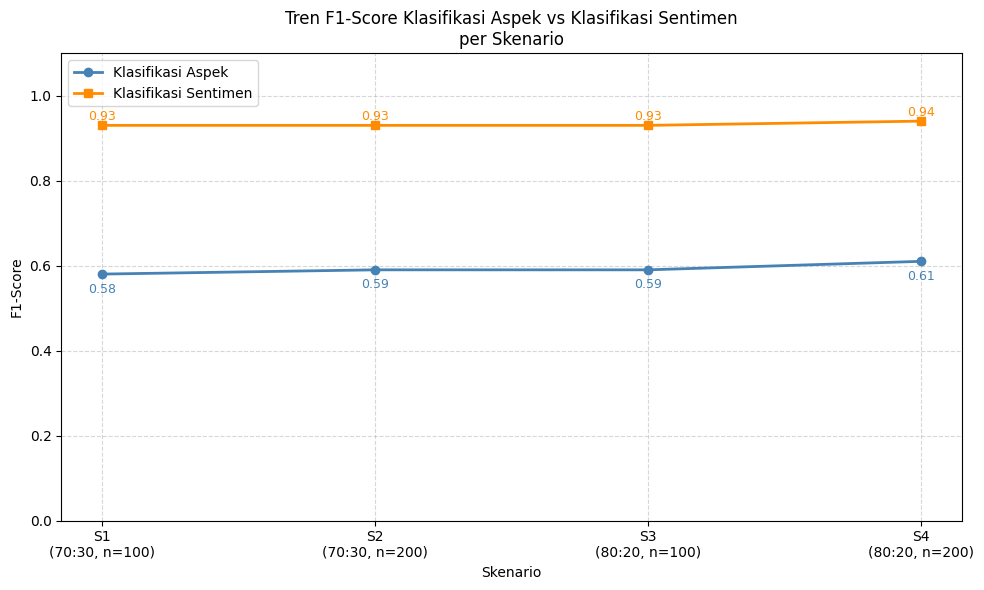

In [ ]:
plot_line_chart(df_aspek, df_sentimen)
